In [1]:
import pandas as pd


df = pd.read_csv('Employee.csv')


print(df.head())


print(df.info())


print(df.describe())

   Education  JoiningYear       City  PaymentTier  Age  Gender EverBenched  \
0  Bachelors         2017  Bangalore            3   34    Male          No   
1  Bachelors         2013       Pune            1   28  Female          No   
2  Bachelors         2014  New Delhi            3   38  Female          No   
3    Masters         2016  Bangalore            3   27    Male          No   
4    Masters         2017       Pune            3   24    Male         Yes   

   ExperienceInCurrentDomain  LeaveOrNot  
0                          0           0  
1                          3           1  
2                          2           0  
3                          5           1  
4                          2           1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1

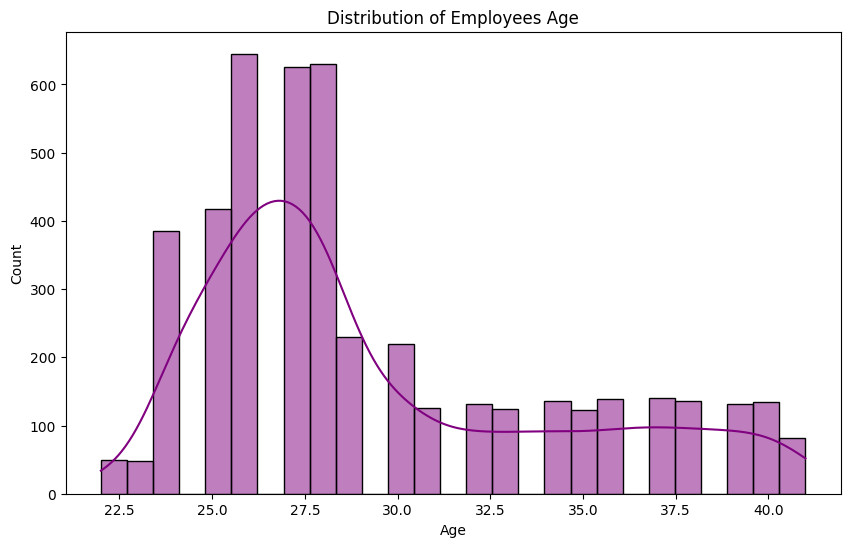

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))


sns.histplot(df['Age'], kde=True, color='purple')


plt.title('Distribution of Employees Age')
plt.xlabel('Age')
plt.ylabel('Count')


plt.show()

/tmp/ipykernel_3000/454681222.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='pastel')


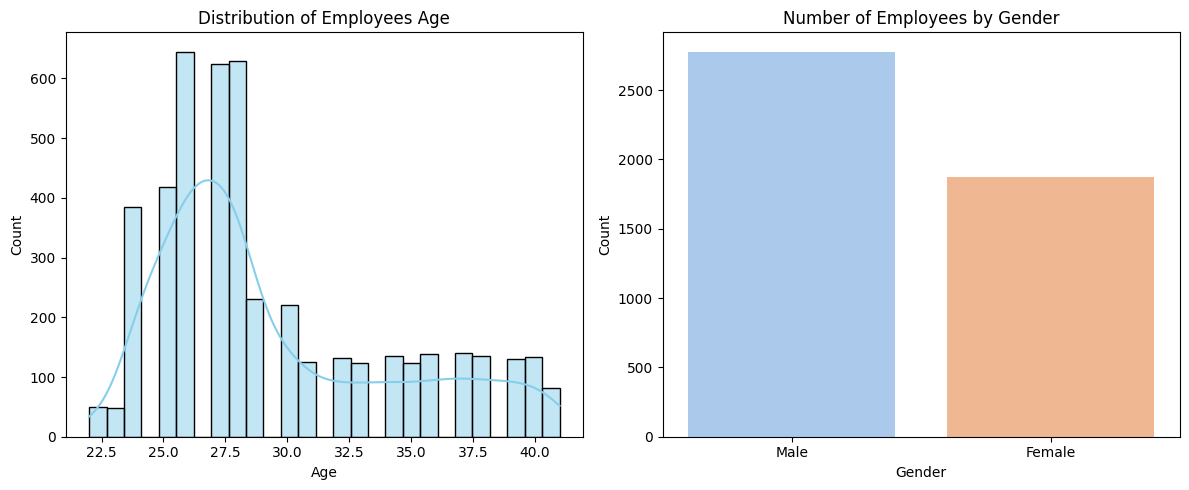

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Distribution of Employees Age')
plt.xlabel('Age')
plt.ylabel('Count')


plt.subplot(1, 2, 2)
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Number of Employees by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')


plt.tight_layout()
plt.show()

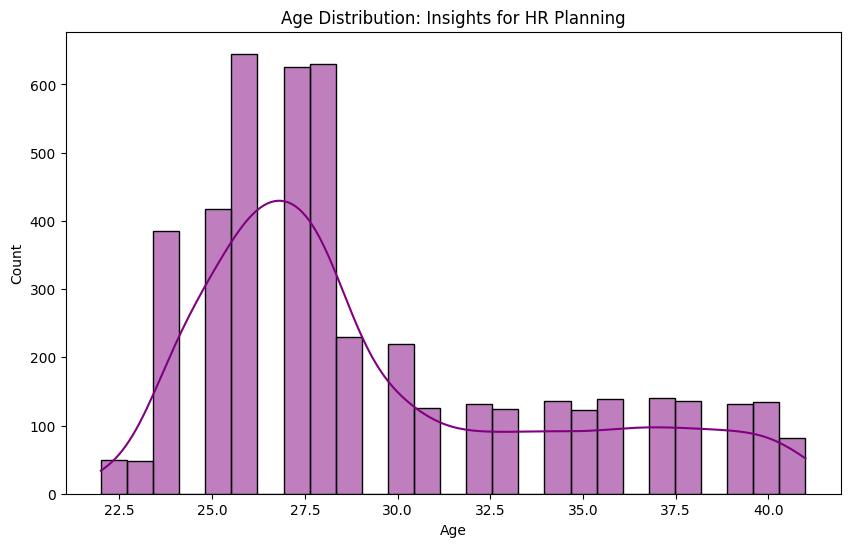

In [4]:
# Analyzing age distribution to understand the workforce generation mix.
# The plot helps HR identify if the company relies more on fresh graduates or senior experts.
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='purple')
plt.title('Age Distribution: Insights for HR Planning')
plt.show()

In [5]:
# Calculating the percentage of employees who left the company (LeaveOrNot = 1)
retention_rate = df['LeaveOrNot'].value_counts(normalize=True) * 100
print("--- Percentage of Employee Attrition ---")
print(f"Stayed: {retention_rate[0]:.2f}%")
print(f"Left: {retention_rate[1]:.2f}%")

--- Percentage of Employee Attrition ---
Stayed: 65.61%
Left: 34.39%


/tmp/ipykernel_3000/2345316543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='City', data=df, order=df['City'].value_counts().index, palette='magma')


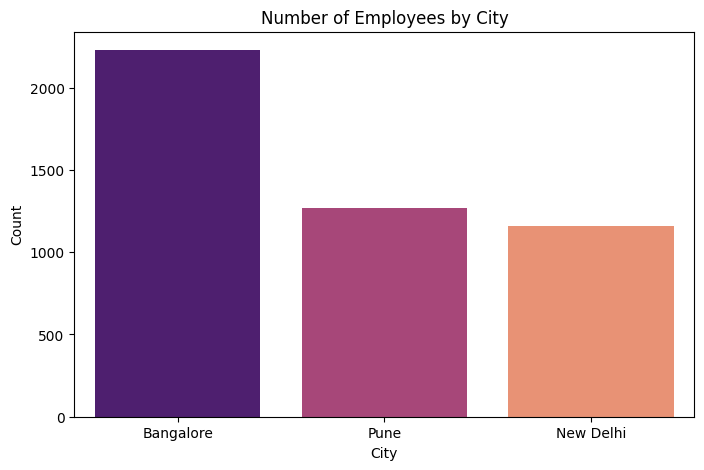

In [6]:
# Visualizing employee distribution across different cities
plt.figure(figsize=(8, 5))
sns.countplot(x='City', data=df, order=df['City'].value_counts().index, palette='magma')
plt.title('Number of Employees by City')
plt.xlabel('City')
plt.ylabel('Count')
plt.show()

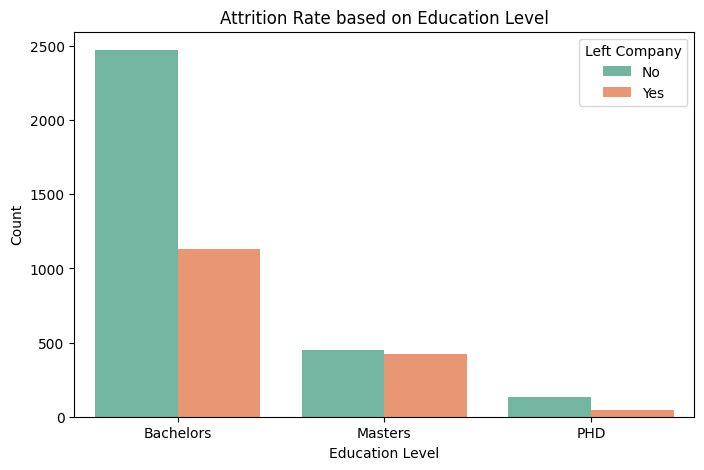

In [7]:
# Exploring the relationship between Education level and Leaving the company
plt.figure(figsize=(8, 5))
sns.countplot(x='Education', hue='LeaveOrNot', data=df, palette='Set2')
plt.title('Attrition Rate based on Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Left Company', labels=['No', 'Yes'])
plt.show()

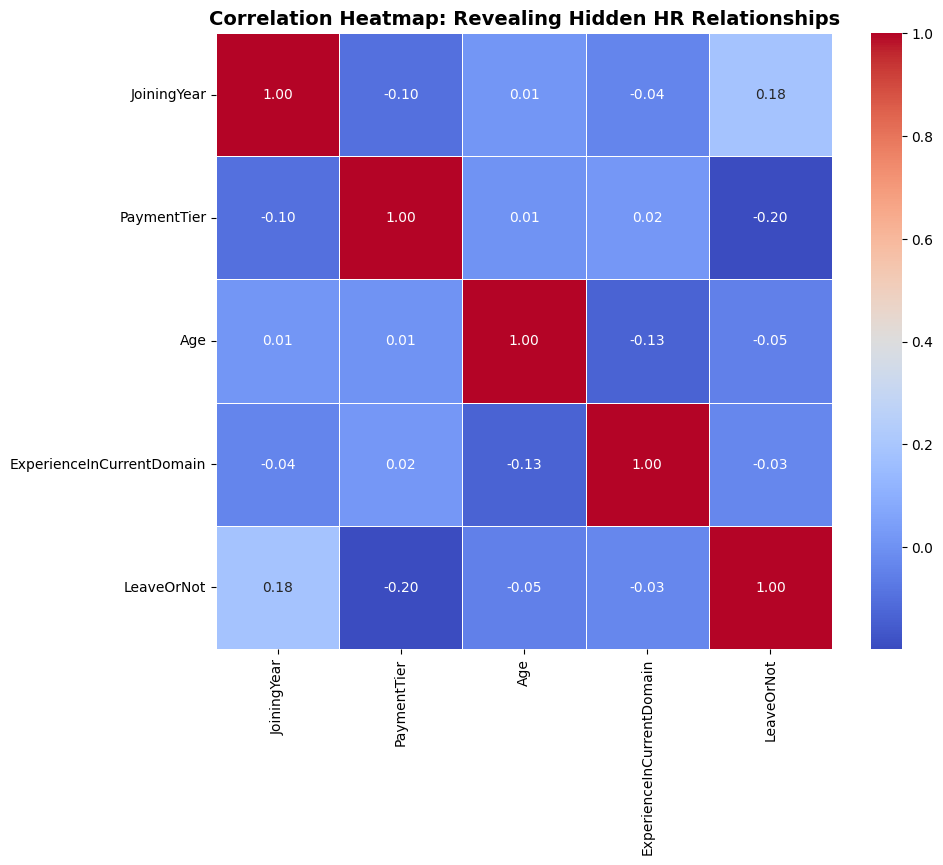

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Business Insight: Identifying hidden correlations between numerical features.
# This heatmap helps us quickly spot which factors most strongly influence an employee's decision to leave.
plt.figure(figsize=(10, 8))


numeric_columns = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_columns.corr()


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title('Correlation Heatmap: Revealing Hidden HR Relationships', fontsize=14, fontweight='bold')
plt.show()

# Insight Summary:
# Notice the correlation value between 'JoiningYear' and 'LeaveOrNot'.
# Positive values mean they move together, negative means they move in opposite directions.

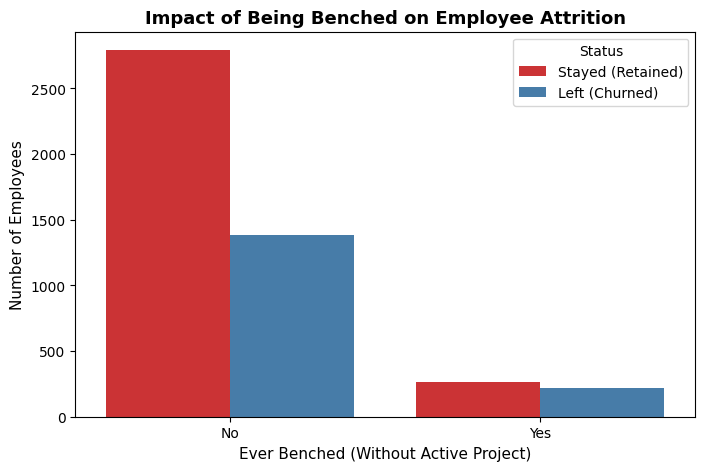

In [9]:
# Business Insight: Evaluating the impact of being "Benched" (no active project) on attrition.
# If benched employees have a high churn rate, the company needs better resource allocation strategies.
plt.figure(figsize=(8, 5))


ax = sns.countplot(x='EverBenched', hue='LeaveOrNot', data=df, palette='Set1')

plt.title('Impact of Being Benched on Employee Attrition', fontsize=13, fontweight='bold')
plt.xlabel('Ever Benched (Without Active Project)', fontsize=11)
plt.ylabel('Number of Employees', fontsize=11)
plt.legend(title='Status', labels=['Stayed (Retained)', 'Left (Churned)'])

plt.show()

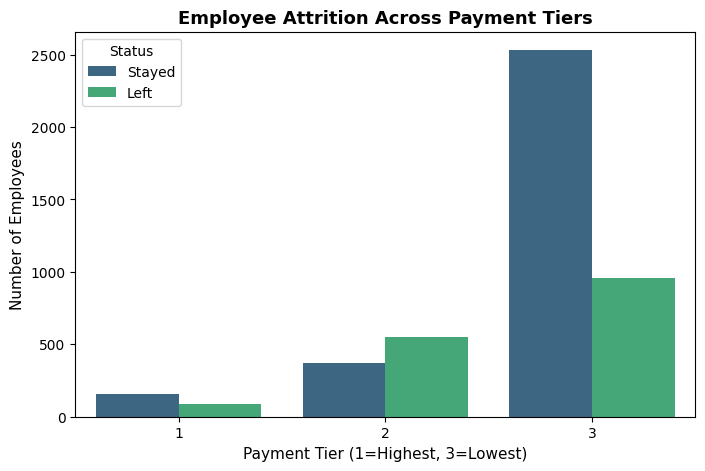

In [10]:
# Business Insight: Assessing if lower payment tiers directly drive employees to leave.
plt.figure(figsize=(8, 5))
sns.countplot(x='PaymentTier', hue='LeaveOrNot', data=df, palette='viridis')

plt.title('Employee Attrition Across Payment Tiers', fontsize=13, fontweight='bold')
plt.xlabel('Payment Tier (1=Highest, 3=Lowest)', fontsize=11)
plt.ylabel('Number of Employees', fontsize=11)
plt.legend(title='Status', labels=['Stayed', 'Left'])

plt.show()

1 Data Loading and Inspection

2 Exploratory Data Analysis

3 Executive Summary & Recommendations



Business Recommendations based on Data:

1   Retention Focus: The company should focus retention efforts on employees in specific cities or payment tiers that show high churn.

2   Bench Management: Minimize the time employees spend "benched" as it may negatively impact their engagement and lead to turnover.

3   Career Development: Evaluate if
the current experience levels align with job roles to prevent stagnation.

